In [1]:
import glob


def get_config_paths(dataset, metric):
    checkpoint_path_list = glob.glob(f"l_checkpoints/{dataset}/*/*/best_{metric}_val_metrics/*")

    config_path_list=[]
    for path in checkpoint_path_list:
        model, version= path.split("/")[2:4]
        config_path = f"config_files/{version}/{model}_{dataset.lower()}_{version}.yaml"
        config_path_list.append(config_path)
    
    return config_path_list, checkpoint_path_list
    


In [2]:
import lightning as L
from src.config import TrainConfig
from src.datamodules import SimpleDataModule
from src.models import get_model
from src.segmentors import SimpleSegmentor
import yaml
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

warnings.filterwarnings(
    "ignore",
    message="You called `self.log",
)

L.seed_everything(42)

Seed set to 42


42

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def test_checkpoint(checkpoint_to_validate: str, config_path: str):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    cfg = TrainConfig(**config)
    model = get_model(cfg.model, **cfg.model_kwargs.model_dump())

    
    

    segmentation_model = SimpleSegmentor.load_from_checkpoint(
        checkpoint_to_validate,
        model=model,
        n_classes=cfg.n_classes,
        criterion=cfg.get_loss(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
        hf_model=cfg.model,
        weights_only=False
    )

    dm = SimpleDataModule(
        dataset_name=cfg.dataset_name,
        batch_size=cfg.batch_size,
        val_test_batch_size=cfg.val_test_batch_size,
    )

    trainer = L.Trainer(
        enable_model_summary=True,
        max_epochs=cfg.max_epochs,
        accelerator="gpu",
        devices=1,
        enable_progress_bar=True,
        accumulate_grad_batches=cfg.grad_accumulation_batches,
        log_every_n_steps=1,
        precision=cfg.precision,
        logger=False,
    )

    return trainer, segmentation_model, dm


# ==========================
# Build dataframe
# ==========================
def get_metrics_plot(df, metric):
    plot_df = pd.DataFrame({
        "Validation v13": df[df["version"] == "v13"].set_index("model")[f"val_metrics/{metric}"],
        "Test v13":       df[df["version"] == "v13"].set_index("model")[f"test_metrics/{metric}"],
        "Validation v14": df[df["version"] == "v14"].set_index("model")[f"val_metrics/{metric}"],
        "Test v14":       df[df["version"] == "v14"].set_index("model")[f"test_metrics/{metric}"],
    })

    plot_df = plot_df.sort_index()

    # ==========================
    # Colors
    # ==========================
    colors = {
        "Validation v13": "#1f77b4",  # dark blue
        "Validation v14": "#9ecae1",  # light blue
        "Test v13": "#d62728",        # dark red
        "Test v14": "#f7b6b2",        # light red
    }

    # ==========================
    # Plot
    # ==========================
    x = np.arange(len(plot_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(
        x - 1.5 * width,
        plot_df["Validation v13"],
        width,
        label="Validation v13",
        color=colors["Validation v13"],
    )

    ax.bar(
        x - 0.5 * width,
        plot_df["Test v13"],
        width,
        label="Test v13",
        color=colors["Test v13"],
    )

    ax.bar(
        x + 0.5 * width,
        plot_df["Validation v14"],
        width,
        label="Validation v14",
        color=colors["Validation v14"],
    )

    ax.bar(
        x + 1.5 * width,
        plot_df["Test v14"],
        width,
        label="Test v14",
        color=colors["Test v14"],
    )

    # ==========================
    # Formatting
    # ==========================
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("Model")
    ax.set_title(f"{metric.upper()} by Model")
    ax.legend()

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

# DeadTrees Miou

In [4]:
from rich import print
from pathlib import Path
import pandas as pd


dataset = "DeadTrees"
metric = "miou"
config_path_vaihingen, checkpoint_path_vaihingen = get_config_paths(dataset, metric)

validation_list = []
for checkpoint, config in zip(checkpoint_path_vaihingen, config_path_vaihingen):

    model, dataset, version = Path(config).stem.split("_")
    print(f"[bold green]Validating checkpoint: {checkpoint} [/bold green]")
    trainer, segmentation_model, dm = test_checkpoint(checkpoint, config)

    validation = trainer.validate(model=segmentation_model, datamodule=dm, verbose=False)
    test = trainer.test(model=segmentation_model, datamodule=dm, verbose=False)
    final_output = dict(model = model, dataset = dataset, version = version) | validation [0] | test[0]
    validation_list.append(final_output)

df = pd.DataFrame(validation_list)
df.to_csv("DeadTrees.csv", index=False)


Validating checkpoint: l_checkpoints/DeadTrees/unetpp/v14/best_miou_val_metrics/miou=0.7433.ckpt 

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

...

Loading weights:   0%|          | 0/307 [00:00<?, ?it/s]

[transformers] UperNetForSemanticSegmentation LOAD REPORT from: openmmlab/upernet-swin-tiny
Key                              | Status   |                                                                                                     
---------------------------------+----------+-----------------------------------------------------------------------------------------------------
auxiliary_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
auxiliary_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight    | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 512, 1, 1]) vs model:torch.Size([2, 512, 1, 1])
decode_head.classifier.bias      | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt w

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

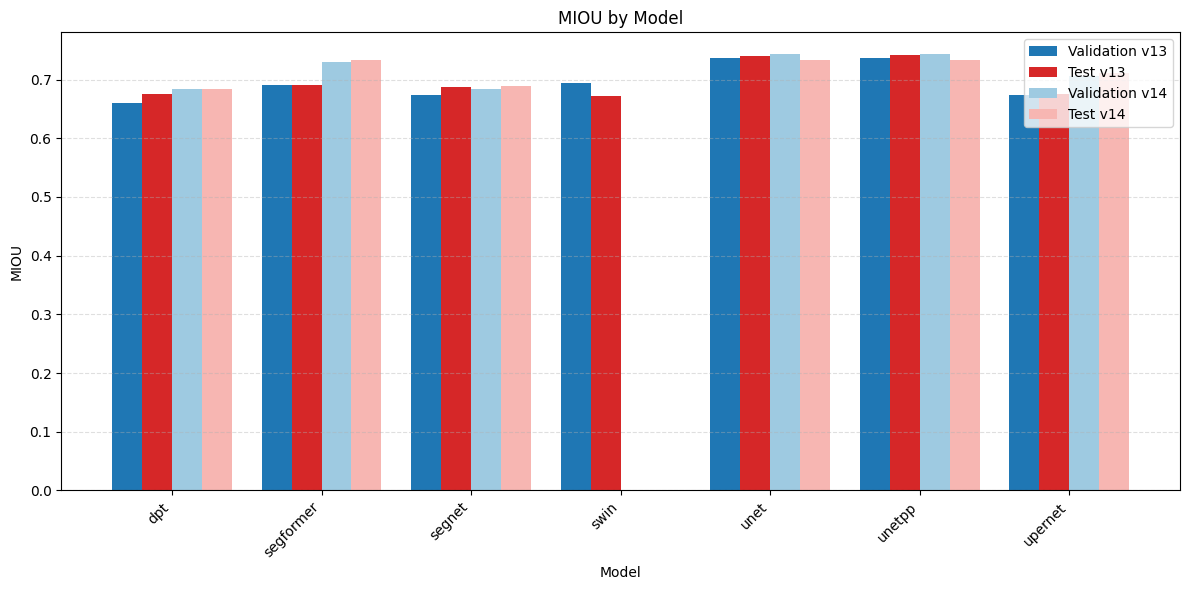

In [5]:
get_metrics_plot(df, metric)

## LoveDA Miou

In [ ]:
dataset = "LoveDA"
metric = "miou"
config_path_vaihingen, checkpoint_path_vaihingen = get_config_paths(dataset, metric)

validation_list = []
for checkpoint, config in zip(checkpoint_path_vaihingen, config_path_vaihingen):

    model, dataset, version = Path(config).stem.split("_")
    print(f"[bold green]Validating checkpoint: {checkpoint} [/bold green]")
    trainer, segmentation_model, dm = test_checkpoint(checkpoint, config)

    validation = trainer.validate(model=segmentation_model, datamodule=dm, verbose=False)
    test = trainer.test(model=segmentation_model, datamodule=dm, verbose=False)
    final_output = dict(model = model, dataset = dataset, version = version) | validation [0] | test[0]
    validation_list.append(final_output)

df = pd.DataFrame(validation_list)
df.to_csv("LoveDA.csv", index=False)


Validating checkpoint: l_checkpoints/LoveDA/unetpp/v14/best_miou_val_metrics/miou=0.3228.ckpt 

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

...

Validating checkpoint: l_checkpoints/LoveDA/segnet/v14/best_miou_val_metrics/miou=0.1629.ckpt 

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

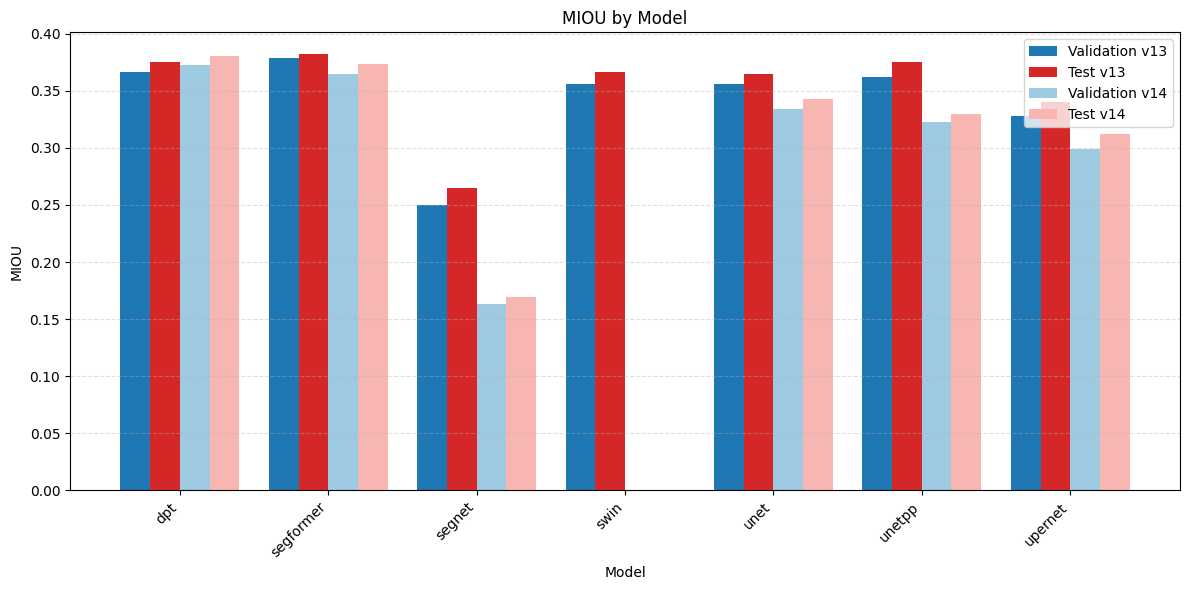

In [7]:
get_metrics_plot(df, metric)

In [1]:
df

NameError: name 'df' is not defined